In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [2]:
offer_events = pd.read_csv("../data/synthetic_enrichment/offer_events.csv")

offer_events.head()

,event_id,subject_key,occurred_at,channel,arm_id,arm_name,reward_probability,reward,idade,profissao,...,numero_contatos_anteriores,resultado_campanha_anterior,taxa_variacao_emprego,indice_preco_consumidor,indice_confianca_consumidor,taxa_euribor_3_meses,numero_empregados,conversao,cliente_ja_contatado,faixa_contatos
0,evt_000001,subject_000001,2025-01-01 00:00:00,whatsapp,0,sem_oferta,0.085,1,56,housemaid,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
1,evt_000002,subject_000002,2025-01-01 00:01:00,email,3,cartao_premium,0.105,0,57,services,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
2,evt_000003,subject_000003,2025-01-01 00:02:00,whatsapp,2,simulador_credito,0.155,0,37,services,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
3,evt_000004,subject_000004,2025-01-01 00:03:00,web,1,educacao_financeira,0.100,0,40,admin.,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1
4,evt_000005,subject_000005,2025-01-01 00:04:00,email,1,educacao_financeira,0.105,0,56,services,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,1


In [3]:
reward_by_arm = (
    offer_events
    .groupby(["arm_id", "arm_name"])["reward"]
    .mean()
    .reset_index()
    .sort_values("reward", ascending=False)
)

reward_by_arm

,arm_id,arm_name,reward
3,3,cartao_premium,0.200605
2,2,simulador_credito,0.173058
1,1,educacao_financeira,0.161490
0,0,sem_oferta,0.105998


In [4]:
random_baseline_reward = offer_events["reward"].mean()

print(f"Reward médio Random Baseline: {random_baseline_reward:.2%}")

Reward médio Random Baseline: 16.01%


In [5]:
arms = sorted(offer_events["arm_id"].unique())

reward_lookup = (
    offer_events
    .groupby("arm_id")["reward"]
    .mean()
    .to_dict()
)

arm_names = (
    offer_events
    .drop_duplicates("arm_id")
    .set_index("arm_id")["arm_name"]
    .to_dict()
)

np.random.seed(42)

alpha = {arm: 1 for arm in arms}
beta = {arm: 1 for arm in arms}

results = []

n_rounds = 10000

for t in range(n_rounds):
    samples = {
        arm: np.random.beta(alpha[arm], beta[arm])
        for arm in arms
    }

    chosen_arm = max(samples, key=samples.get)

    reward_probability = reward_lookup[chosen_arm]

    reward = np.random.binomial(
        n=1,
        p=reward_probability
    )

    if reward == 1:
        alpha[chosen_arm] += 1
    else:
        beta[chosen_arm] += 1

    results.append({
        "round": t + 1,
        "arm_id": chosen_arm,
        "arm_name": arm_names[chosen_arm],
        "reward": reward
    })

ts_results = pd.DataFrame(results)

ts_results.head()

,round,arm_id,arm_name,reward
0,1,0,sem_oferta,0
1,2,3,cartao_premium,0
2,3,1,educacao_financeira,0
3,4,2,simulador_credito,0
4,5,0,sem_oferta,0


In [6]:
thompson_reward = ts_results["reward"].mean()

comparison = pd.DataFrame([
    {
        "policy": "Random Baseline",
        "reward_mean": random_baseline_reward
    },
    {
        "policy": "Thompson Sampling",
        "reward_mean": thompson_reward
    }
])

comparison["reward_mean_pct"] = comparison["reward_mean"] * 100

comparison

,policy,reward_mean,reward_mean_pct
0,Random Baseline,0.160144,16.014373
1,Thompson Sampling,0.192300,19.230000


In [7]:
uplift = (
    (thompson_reward - random_baseline_reward)
    / random_baseline_reward
)

print(f"Uplift Thompson vs Baseline: {uplift:.2%}")

Uplift Thompson vs Baseline: 20.08%


In [8]:
choice_distribution = (
    ts_results["arm_name"]
    .value_counts(normalize=True)
    .reset_index()
)

choice_distribution.columns = ["arm_name", "share"]

choice_distribution

,arm_name,share
0,cartao_premium,0.7443
1,simulador_credito,0.1843
2,educacao_financeira,0.0627
3,sem_oferta,0.0087


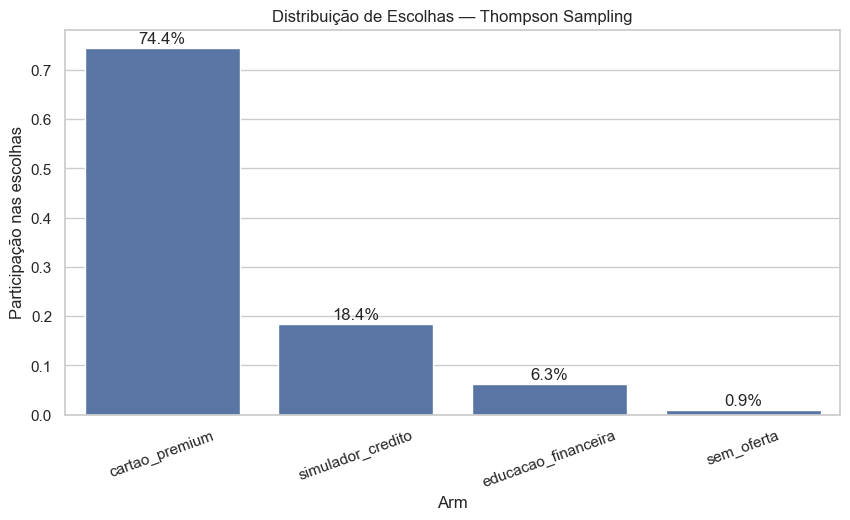

In [9]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=choice_distribution,
    x="arm_name",
    y="share"
)

for i, row in choice_distribution.iterrows():
    ax.text(
        i,
        row["share"] + 0.01,
        f"{row['share']:.1%}",
        ha="center"
    )

plt.title("Distribuição de Escolhas — Thompson Sampling")
plt.xlabel("Arm")
plt.ylabel("Participação nas escolhas")
plt.xticks(rotation=20)
plt.show()

In [10]:
ts_results["cumulative_reward"] = ts_results["reward"].cumsum()
ts_results["average_reward"] = ts_results["cumulative_reward"] / ts_results["round"]

ts_results.head()

,round,arm_id,arm_name,reward,cumulative_reward,average_reward
0,1,0,sem_oferta,0,0,0.0
1,2,3,cartao_premium,0,0,0.0
2,3,1,educacao_financeira,0,0,0.0
3,4,2,simulador_credito,0,0,0.0
4,5,0,sem_oferta,0,0,0.0


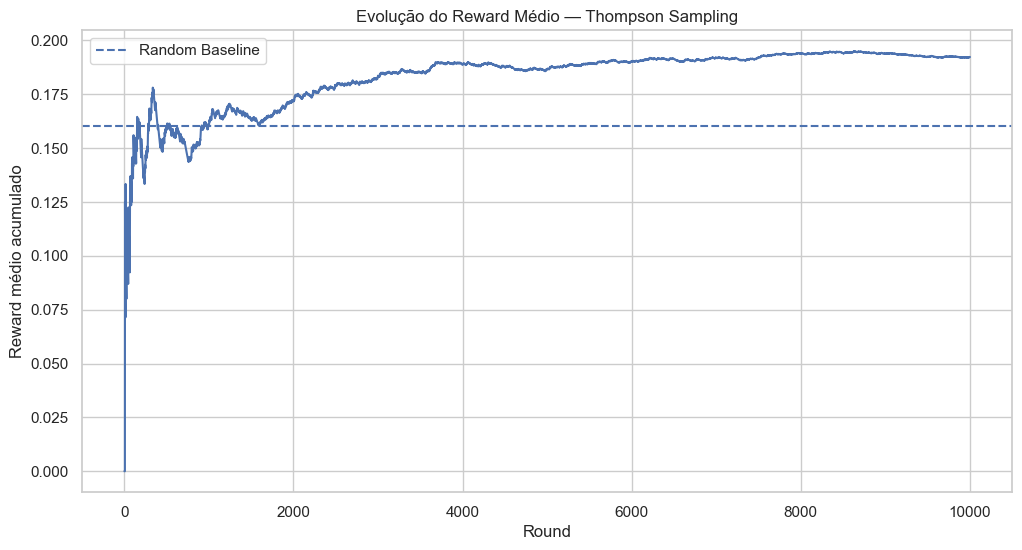

In [11]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=ts_results,
    x="round",
    y="average_reward"
)

plt.axhline(
    random_baseline_reward,
    linestyle="--",
    label="Random Baseline"
)

plt.title("Evolução do Reward Médio — Thompson Sampling")
plt.xlabel("Round")
plt.ylabel("Reward médio acumulado")
plt.legend()
plt.show()

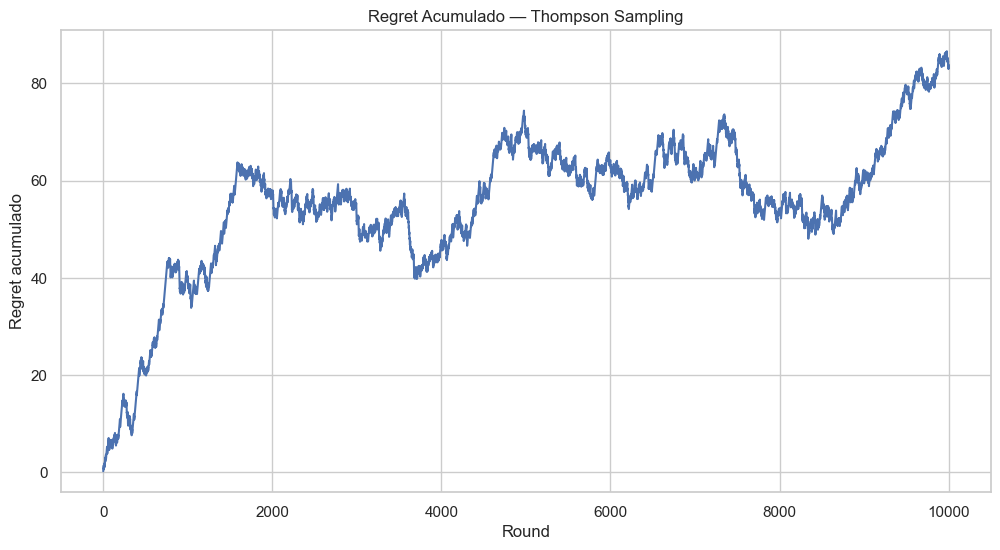

In [12]:
best_arm_reward = max(reward_lookup.values())

ts_results["instant_regret"] = best_arm_reward - ts_results["reward"]
ts_results["cumulative_regret"] = ts_results["instant_regret"].cumsum()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=ts_results,
    x="round",
    y="cumulative_regret"
)

plt.title("Regret Acumulado — Thompson Sampling")
plt.xlabel("Round")
plt.ylabel("Regret acumulado")
plt.show()

In [15]:
ts_results["cumulative_reward"] = (
    ts_results["reward"]
    .cumsum()
)

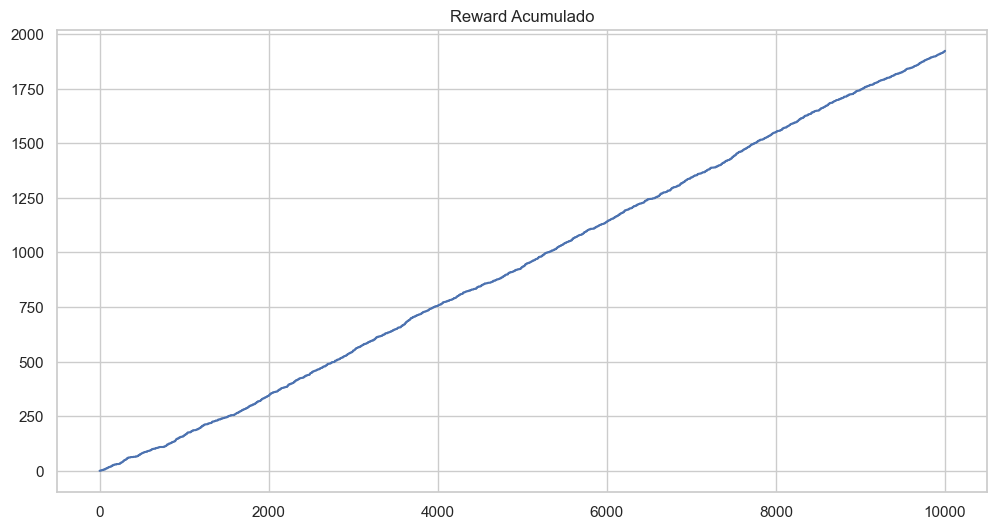

In [16]:
plt.figure(figsize=(12,6))

plt.plot(
    ts_results["round"],
    ts_results["cumulative_reward"]
)

plt.title("Reward Acumulado")
plt.show()

In [17]:
ts_results["window"] = (
    ts_results["round"] // 500
)

arm_evolution = (
    ts_results
    .groupby(["window", "arm_name"])
    .size()
    .reset_index(name="count")
)

<Axes: xlabel='window', ylabel='count'>

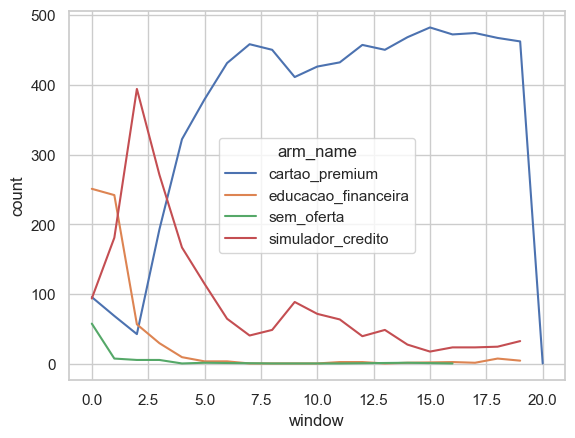

In [18]:
sns.lineplot(
    data=arm_evolution,
    x="window",
    y="count",
    hue="arm_name"
)

## Conclusão

A avaliação offline comparou uma política baseline aleatória com uma política adaptativa baseada em Thompson Sampling.

O baseline representa um cenário sem aprendizado, no qual os braços são distribuídos de forma aleatória. Já o Thompson Sampling utiliza exploração bayesiana para aprender progressivamente quais braços apresentam maior recompensa esperada.

Os resultados indicam que a política adaptativa concentrou mais decisões nos braços com maior taxa de reward, especialmente no braço com melhor desempenho observado, aumentando o reward médio em relação ao baseline.

Essa avaliação demonstra o valor da abordagem adaptativa para reduzir desperdício de tráfego e priorizar ofertas com maior retorno esperado.